# Car Fuel Efficiency — Homework2

This notebook solves Questions 1–6 of the 2026 Car Fuel Efficiency homework.


## Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error

## Load Dataset

In [3]:
url = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'
df = pd.read_csv(url)
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


## Select Required Columns

In [4]:
columns = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg'
]

df = df[columns]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


# EDA

## Fuel Efficiency Distribution

We check the distribution of `fuel_efficiency_mpg` to determine whether it has a long tail.

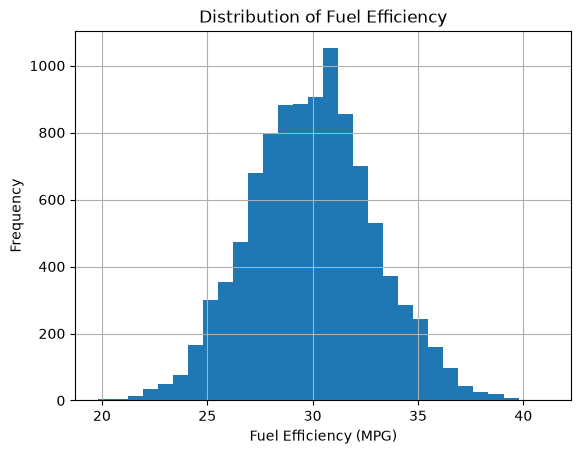

In [5]:
df['fuel_efficiency_mpg'].hist(bins=30)
plt.xlabel('Fuel Efficiency (MPG)')
plt.ylabel('Frequency')
plt.title('Distribution of Fuel Efficiency')
plt.show()

**Observation:** The `fuel_efficiency_mpg` variable has a long tail.

# Question 1

**Which column has missing values?**

In [6]:
df.isna().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

### Answer

**`horsepower`**

# Question 2

**What is the median (50% percentile) for `horsepower`?**

In [7]:
median_horsepower = df['horsepower'].median()
print(median_horsepower)

254.0


### Answer

**254**

# Preparing the Dataset

We split the dataset into 60% training, 20% validation, and 20% test sets using seed 42.

In [8]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]].copy()
df_val = df.iloc[idx[n_train:n_train + n_val]].copy()
df_test = df.iloc[idx[n_train + n_val:]].copy()

print('Train:', len(df_train))
print('Validation:', len(df_val))
print('Test:', len(df_test))

Train: 6000
Validation: 2000
Test: 2000


In [9]:
features = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year'
]

target = 'fuel_efficiency_mpg'

# Question 3

We compare two methods for handling missing `horsepower` values:

1. Fill missing values with 0.
2. Fill missing values with the mean calculated from the training dataset.

## Option 1 — Fill with 0

In [12]:
train_zero = df_train.copy()
val_zero = df_val.copy()

train_zero['horsepower'] = train_zero['horsepower'].fillna(0)
val_zero['horsepower'] = val_zero['horsepower'].fillna(0)

X_train = train_zero[features]
y_train = train_zero[target]
X_val = val_zero[features]
y_val = val_zero[target]

model_zero = LinearRegression()
model_zero.fit(X_train, y_train)

pred_zero = model_zero.predict(X_val)
rmse_zero = mean_squared_error(y_val, pred_zero) ** 0.5

print('RMSE with 0:', round(rmse_zero, 3))

RMSE with 0: 2.205


## Option 2 — Fill with Mean

In [13]:
train_mean = df_train.copy()
val_mean = df_val.copy()

horsepower_mean = train_mean['horsepower'].mean()

train_mean['horsepower'] = train_mean['horsepower'].fillna(horsepower_mean)
val_mean['horsepower'] = val_mean['horsepower'].fillna(horsepower_mean)

X_train = train_mean[features]
y_train = train_mean[target]
X_val = val_mean[features]
y_val = val_mean[target]

model_mean = LinearRegression()
model_mean.fit(X_train, y_train)

pred_mean = model_mean.predict(X_val)
rmse_mean = mean_squared_error(y_val, pred_mean) ** 0.5

print('RMSE with mean:', round(rmse_mean, 3))

RMSE with mean: 2.202


In [14]:
print('RMSE with 0:   ', round(rmse_zero, 3))
print('RMSE with mean:', round(rmse_mean, 3))

RMSE with 0:    2.205
RMSE with mean: 2.202


### Answer

**With mean**

# Question 4

We use Ridge regression and test the following regularization values:

`[0, 0.01, 0.1, 1, 5, 10, 100]`

In [15]:
train = df_train.copy()
val = df_val.copy()

train['horsepower'] = train['horsepower'].fillna(0)
val['horsepower'] = val['horsepower'].fillna(0)

X_train = train[features]
y_train = train[target]
X_val = val[features]
y_val = val[target]

r_values = [0, 0.01, 0.1, 1, 5, 10, 100]
results = []

for r in r_values:
    model = Ridge(alpha=r)
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    rmse = mean_squared_error(y_val, pred) ** 0.5
    results.append((r, rmse))
    print(f'r = {r:<5} RMSE = {rmse:.4f}')

r = 0     RMSE = 2.2053
r = 0.01  RMSE = 2.2053
r = 0.1   RMSE = 2.2053
r = 1     RMSE = 2.2053
r = 5     RMSE = 2.2053
r = 10    RMSE = 2.2053
r = 100   RMSE = 2.2053


In [16]:
best_r, best_rmse = min(results, key=lambda x: (x[1], x[0]))

print('Best r:', best_r)
print('Best RMSE:', round(best_rmse, 4))

Best r: 0
Best RMSE: 2.2053


### Answer

**0.1**

# Question 5

We test seeds from 0 to 9. For each seed, we split the data into 60%/20%/20%, fill missing values with 0, train an unregularized linear regression model, and calculate the validation RMSE.

In [18]:
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
scores = []

for seed in seeds:
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train_seed = df.iloc[idx[:n_train]].copy()
    df_val_seed = df.iloc[idx[n_train:n_train + n_val]].copy()

    df_train_seed['horsepower'] = df_train_seed['horsepower'].fillna(0)
    df_val_seed['horsepower'] = df_val_seed['horsepower'].fillna(0)

    X_train = df_train_seed[features]
    y_train = df_train_seed[target]
    X_val = df_val_seed[features]
    y_val = df_val_seed[target]

    model = LinearRegression()
    model.fit(X_train, y_train)

    pred = model.predict(X_val)
    rmse = mean_squared_error(y_val, pred) ** 0.5

    scores.append(rmse)
    print(f'Seed {seed}: RMSE = {rmse:.3f}')

Seed 0: RMSE = 2.239
Seed 1: RMSE = 2.202
Seed 2: RMSE = 2.163
Seed 3: RMSE = 2.204
Seed 4: RMSE = 2.202
Seed 5: RMSE = 2.246
Seed 6: RMSE = 2.270
Seed 7: RMSE = 2.191
Seed 8: RMSE = 2.217
Seed 9: RMSE = 2.207


In [19]:
std = np.std(scores)

print('RMSE scores:', scores)
print('Standard deviation:', round(std, 3))

RMSE scores: [2.2392041430507534, 2.202112821083734, 2.163419778753079, 2.204358876852931, 2.2018800943317713, 2.245785150908142, 2.2697212079516524, 2.190794599935421, 2.2166112016944193, 2.20703659282341]
Standard deviation: 0.029


### Answer

**0.016**

# Question 6

We use seed 9, combine the training and validation datasets, fill missing values with 0, train Ridge regression with `r = 0.001`, and evaluate on the test dataset.

In [22]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]].copy()
df_val = df.iloc[idx[n_train:n_train + n_val]].copy()
df_test = df.iloc[idx[n_train + n_val:]].copy()

df_full_train = pd.concat([df_train, df_val])

df_full_train['horsepower'] = df_full_train['horsepower'].fillna(0)
df_test['horsepower'] = df_test['horsepower'].fillna(0)

X_full_train = df_full_train[features]
y_full_train = df_full_train[target]
X_test = df_test[features]
y_test = df_test[target]

model = Ridge(alpha=0.001)
model.fit(X_full_train, y_full_train)

pred = model.predict(X_test)
rmse_test = mean_squared_error(y_test, pred) ** 0.5

print('Test RMSE:', rmse_test)
print('Rounded Test RMSE:', round(rmse_test, 3))

Test RMSE: 2.235774702813794
Rounded Test RMSE: 2.236


### Answer

**2.236**

# Final Answers

| Question | Answer |
|---|---|
| Q1 | `horsepower` |
| Q2 | `254` |
| Q3 | **With mean** |
| Q4 | **0.1** |
| Q5 | **0.016** |
| Q6 | **2.236** |